# 07 – Hα Activity Tracking via Latent Space & Lomb-Scargle Periodograms

This notebook isolates the region around the Hα spectral line (order 25) to investigate whether latent space representations from a denoising autoencoder capture meaningful stellar activity.

I aim to:

- Crop order 25 around the Hα line (6563 Å).
- Train an autoencoder using only this region.
- Use the latent space to identify periodic signals related to stellar rotation.
- Evaluate correlation with HALPHA and SNR_25.
- Use Lomb-Scargle periodograms and false alarm probabilities (FAP) to assess periodicity.
- Visualize spectral evolution over time as a GIF (original + reconstructed).
- Try reducing the resolution.
- Implement a Contractive Loss.
- Apply regularization after every layer in encoder and decoder.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.timeseries import LombScargle
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import os
import imageio
from astropy.timeseries import LombScargle
import umap
import seaborn as sns
from scipy.stats import spearmanr

2025-05-05 12:59:10.458990: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-05 12:59:10.557522: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746442750.604909   10430 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746442750.622039   10430 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746442750.720650   10430 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
HA_CENTER = 6563  # Ångstroms
CROP_WIDTH = 22   # Å (± around center) If we use other values that are not divisble by this, we need to change the number of pixels in the spectra - 22
PIXELS = 4096

fits_root = "../../aumicAE"
order = 25

In [10]:
meta = pd.read_csv("../outputs/aligned_metadata/aligned_metadata_snr_filtered.csv")
meta = meta.sort_values("BJD").reset_index(drop=True)

**Load Data**

In [11]:
with open("../data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = [os.path.join(fits_root, line.strip().lstrip("../")) for line in f if line.strip()]

# Sort by BJD
vis_a_files = [f for _, f in sorted(zip(meta["BJD"], vis_a_files))]

#### Reduce Resolution

**Defining a Binning Function:**

Bin (average) the spectrum into groups of bin_size pixels.

In [12]:
def bin_spectrum(spectrum, bin_size):
    n_bins = len(spectrum) // bin_size
    spectrum = spectrum[:n_bins * bin_size]  # Cut to full bins
    binned = spectrum.reshape(n_bins, bin_size).mean(axis=1)
    return binned

**Crop Order 25**

In [13]:
def extract_ha_region(file_path, order=25, bin_size=None):
    with fits.open(file_path) as hdul:
        flux = hdul["SPEC"].data[order]
        cont = hdul["CONT"].data[order]
        wave = hdul["WAVE"].data[order]

        continuum = np.where(np.isfinite(cont) & (cont > 1e-3), cont, 1.0)
        norm_flux = flux / continuum
        norm_flux = np.nan_to_num(norm_flux, nan=0.0, posinf=5.0, neginf=0.0)
        norm_flux = np.clip(norm_flux, 0.0, 5.0)

        mask = (wave >= HA_CENTER - CROP_WIDTH) & (wave <= HA_CENTER + CROP_WIDTH)
        cropped_flux = norm_flux[mask]

        # Binning step
        if bin_size is not None and bin_size > 1:
            cropped_flux = bin_spectrum(cropped_flux, bin_size)

        return cropped_flux.astype(np.float32)

**Spectra WITHOUT Binning**

In [14]:
spectra_crop = [extract_ha_region(f) for f in vis_a_files]
X_crop = np.stack(spectra_crop)
print("Original cropped shape:", X_crop.shape)

Original cropped shape: (95, 1472)


**Spectra WITH Binning**

In [15]:
BIN_SIZE = 4  # we could hoose 2, 4, 8, etc.

spectra_crop_binned = [extract_ha_region(f, bin_size=BIN_SIZE) for f in vis_a_files]
X_crop_binned = np.stack(spectra_crop_binned)
print("Binned cropped shape:", X_crop_binned.shape)

Binned cropped shape: (95, 368)


**Load SNR_25 from FITS headers**

In [16]:
snr_values = []

for file in vis_a_files:
    with fits.open(file) as hdul:
        header = hdul[0].header
        snr = header.get("HIERARCH CARACAL FOX SNR 30", np.nan)
        snr_values.append(snr)

SNR_25 = np.array(snr_values)
snr_norm = (SNR_25 - np.mean(SNR_25)) / np.std(SNR_25)

## Autoencoder

#### Method Selection

In [17]:
LATENT_DIM = 18 # 18 was better
USE_WEIGHTED_LOSS = False # False 
USE_DECORR_PENALTY = False
ALPHA_VAL = 5.0 # 1.0
USE_LATENT_NORM = True
USE_NOISE = False  
NOISE_STD = 1.0
EXCLUDED_DIMS = [0, 1, 2, 3, 4, 5, 6, 7, 8]
EPOCHS_NUM = 100
PATIENCE_EPOCHS = 5
ACTIVATION_FUNC = "sigmoid"
BATCH_SIZE = 8
EARLY_DROP=0.0
MID_DROP=0.0 
DEEP_DROP=0.0
LATENT_DROP=0.0
DECODER_DROP=0.0
X_crop = X_crop # X_crop_binned
INPUT_LEN = X_crop.shape[1]
CONTRACTIVE_LOSS = True
LAMBDA = 1e-4
REG_STRENGTH = 1e-4

#### Adding Gaussian Noise

In [18]:
def add_gaussian_noise(X, std=0.05):
    noise = np.random.normal(loc=0.0, scale=std, size=X.shape)
    return np.clip(X + noise, 0.0, 5.0)

#### **Architecture**

In [19]:
def build_autoencoder(latent_dim, reg_strength=None):
    input_layer = layers.Input(shape=(INPUT_LEN, 1))

    reg = regularizers.l1(reg_strength) if reg_strength else None

    # Encoder
    x = layers.Conv1D(16, 5, activation='relu', padding='same', activity_regularizer=reg)(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(EARLY_DROP)(x)
    x = layers.MaxPooling1D(4)(x)

    x = layers.Conv1D(8, 3, activation='relu', padding='same', activity_regularizer=reg)(x)
    x = layers.Dropout(MID_DROP)(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(8, 3, activation='relu', padding='same', activity_regularizer=reg)(x)
    x = layers.Dropout(DEEP_DROP)(x)
    x = layers.MaxPooling1D(2)(x)

    compressed_len = INPUT_LEN // (4 * 2 * 2)

    x = layers.Flatten()(x)

    latent = layers.Dense(latent_dim, name="latent", activity_regularizer=reg)(x)
    latent = layers.Dropout(LATENT_DROP)(latent)
    if USE_LATENT_NORM:
        latent = layers.LayerNormalization()(latent)

    # Decoder
    x = layers.Dense(compressed_len * 8, activation='relu', activity_regularizer=reg)(latent)
    x = layers.Reshape((compressed_len, 8))(x)

    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(8, 3, activation='relu', padding='same', activity_regularizer=reg)(x)
    x = layers.Dropout(DECODER_DROP)(x)

    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(8, 3, activation='relu', padding='same', activity_regularizer=reg)(x)

    x = layers.UpSampling1D(4)(x)
    decoded = layers.Conv1D(1, 3, activation=ACTIVATION_FUNC, padding='same', activity_regularizer=reg)(x)

    model = models.Model(input_layer, decoded)
    encoder = models.Model(input_layer, latent)
    return model, encoder

**Partial Correlation Penalty**

In [20]:
def partial_correlation_penalty(latent_output, snr_tensor, alpha=0.1, exclude_dims=None):
    latent_mean = tf.reduce_mean(latent_output, axis=0)
    snr_mean = tf.reduce_mean(snr_tensor)

    latent_centered = latent_output - latent_mean
    snr_centered = snr_tensor - snr_mean

    corr_numer = tf.reduce_sum(latent_centered * tf.expand_dims(snr_centered, axis=1), axis=0)
    corr_denom = tf.sqrt(tf.reduce_sum(tf.square(latent_centered), axis=0)) * tf.sqrt(tf.reduce_sum(tf.square(snr_centered)))
    correlation = corr_numer / (corr_denom + 1e-6)

    if exclude_dims is not None:
        mask = tf.ones_like(correlation)
        mask_numpy = np.ones(mask.shape, dtype=bool)
        mask_numpy[exclude_dims] = False
        mask = tf.constant(mask_numpy, dtype=tf.float32)
        correlation = correlation * mask

    penalty = alpha * tf.reduce_mean(tf.square(correlation))
    return penalty

### **Contractive Loss**

Penalty = ∑((h(1−h))^2⋅∑W^2)

where:

W are the weights of the encoder layer

h(1−h)h(1−h) comes from the derivative of the sigmoid activation

We sum over all latent units.

In [21]:
def contractive_loss(x, recon, latent, model, lam=1e-4):
    mse = tf.reduce_mean(tf.square(x - recon), axis=[1, 2])
    W = model.get_layer('latent').weights[0]  # shape (flattened_input, latent_dim)
    h = latent
    dh = h * (1 - h)  # derivative if we use sigmoid; we need to adjust if different!
    penalty = tf.reduce_sum((dh ** 2) * tf.reduce_sum(W ** 2, axis=0), axis=1)
    return tf.reduce_mean(mse + lam * penalty)

**Normalize Latent Vectors**

In [22]:
def normalize_latent(latent):
    mean = np.mean(latent, axis=0)
    std = np.std(latent, axis=0) + 1e-6
    return (latent - mean) / std

### **Training Loop**

In [23]:
class SNRTrainer(tf.keras.Model):
    def __init__(self, autoencoder, latent_layer_name="latent", alpha=0.1, exclude_dims=None,
                 use_weighted_loss=False, use_decorrelation=False, use_contractive_loss=False):
        super().__init__()
        self.autoencoder = autoencoder
        self.latent_layer = autoencoder.get_layer(latent_layer_name).output
        self.encoder = tf.keras.Model(autoencoder.input, self.latent_layer)
        self.alpha = alpha
        self.exclude_dims = exclude_dims
        self.use_weighted_loss = use_weighted_loss
        self.use_decorrelation = use_decorrelation
        self.use_contractive_loss = use_contractive_loss

    def compile(self, optimizer):
        super().compile()
        self.optimizer = optimizer

    def train_step(self, data):
        X_batch, snr_raw = data

        snr_weights_batch = snr_raw / (tf.reduce_mean(snr_raw) + 1e-6)
        snr_weights_batch = tf.clip_by_value(snr_weights_batch, 0.1, 10.0)

        with tf.GradientTape() as tape:
            recon = self.autoencoder(X_batch, training=True)
            latent = self.encoder(X_batch, training=True)
            recon_error = tf.reduce_mean(tf.square(X_batch - recon), axis=[1, 2])

            if self.use_weighted_loss:
                loss_recon = tf.reduce_mean(recon_error * snr_weights_batch)
            else:
                loss_recon = tf.reduce_mean(recon_error)

            loss_corr = tf.constant(0.0, dtype=tf.float32)
            if self.use_decorrelation:
                loss_corr = partial_correlation_penalty(
                    latent, snr_weights_batch, alpha=self.alpha, exclude_dims=self.exclude_dims
                )

            loss_contractive = tf.constant(0.0, dtype=tf.float32)
            if self.use_contractive_loss:
                W = self.autoencoder.get_layer('latent').weights[0]
                h = latent
                dh = h * (1 - h)
                penalty = tf.reduce_sum((dh ** 2) * tf.reduce_sum(W ** 2, axis=0), axis=1)
                loss_contractive = tf.reduce_mean(penalty)

            total_loss = loss_recon + loss_corr + LAMBDA * loss_contractive

        grads = tape.gradient(total_loss, self.autoencoder.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.autoencoder.trainable_variables))

        return {
            "loss": total_loss,
            "recon_loss": loss_recon,
            "decorrelation_penalty": loss_corr,
            "contractive_penalty": loss_contractive if self.use_contractive_loss else tf.constant(0.0)
        }


### Create and Compile Trainer

In [24]:
X_input = add_gaussian_noise(X_crop, NOISE_STD).astype(np.float32) if USE_NOISE else X_crop.astype(np.float32)
X_input = X_input[..., np.newaxis]
snr_tensor = tf.convert_to_tensor(snr_norm[:len(X_input)], dtype=tf.float32)

autoencoder, encoder = build_autoencoder(LATENT_DIM, reg_strength=REG_STRENGTH)
trainer = SNRTrainer(
    autoencoder,
    alpha=ALPHA_VAL,
    exclude_dims=EXCLUDED_DIMS,
    use_weighted_loss=USE_WEIGHTED_LOSS,
    use_decorrelation=USE_DECORR_PENALTY,
    use_contractive_loss=CONTRACTIVE_LOSS
)
trainer.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

2025-05-05 12:59:45.984052: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Dataset + Training

In [25]:
dataset = tf.data.Dataset.from_tensor_slices((X_input, snr_tensor))
dataset = dataset.shuffle(buffer_size=len(X_input)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE) # lets TensorFlow dynamically choose the optimal number of batches to prefetch based on system resources (e.g. CPU/GPU load)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="recon_loss", 
    patience=PATIENCE_EPOCHS,
    restore_best_weights=True,
    mode="min"
)

trainer.fit(dataset, epochs=EPOCHS_NUM, callbacks=[early_stopping], verbose=2)

Epoch 1/100


2025-05-05 12:59:48.185148: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


12/12 - 2s - 189ms/step - contractive_penalty: 4.3853 - decorrelation_penalty: 0.0000e+00 - loss: 0.0993 - recon_loss: 0.0989
Epoch 2/100
12/12 - 0s - 10ms/step - contractive_penalty: 1.9155 - decorrelation_penalty: 0.0000e+00 - loss: 0.0530 - recon_loss: 0.0528
Epoch 3/100
12/12 - 0s - 10ms/step - contractive_penalty: 1.1689 - decorrelation_penalty: 0.0000e+00 - loss: 0.0093 - recon_loss: 0.0092
Epoch 4/100
12/12 - 0s - 9ms/step - contractive_penalty: 0.9632 - decorrelation_penalty: 0.0000e+00 - loss: 0.0109 - recon_loss: 0.0108
Epoch 5/100
12/12 - 0s - 8ms/step - contractive_penalty: 2.6227 - decorrelation_penalty: 0.0000e+00 - loss: 0.0038 - recon_loss: 0.0036
Epoch 6/100
12/12 - 0s - 8ms/step - contractive_penalty: 1.5770 - decorrelation_penalty: 0.0000e+00 - loss: 0.0020 - recon_loss: 0.0018
Epoch 7/100
12/12 - 0s - 8ms/step - contractive_penalty: 1.1176 - decorrelation_penalty: 0.0000e+00 - loss: 0.0021 - recon_loss: 0.0020
Epoch 8/100
12/12 - 0s - 9ms/step - contractive_penalty:

### Save Latents for Analysis

In [26]:
Z = encoder.predict(X_crop)
if USE_LATENT_NORM:
    Z = normalize_latent(Z)

np.save("../outputs/latent/latent_vectors_halpha_focus.npy", Z)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


### Decorrelated Latent Space

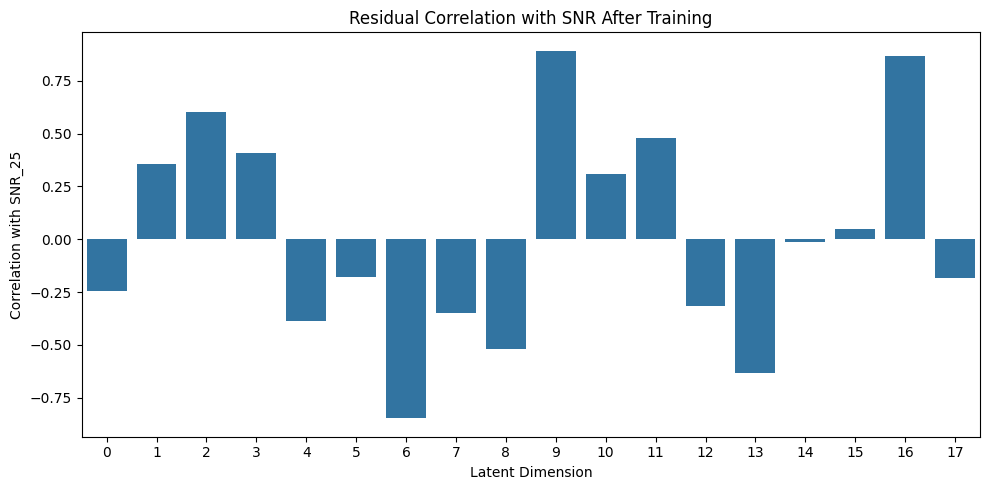

In [27]:
corrs = [np.corrcoef(Z[:, i], snr_norm[:len(Z)])[0, 1] for i in range(Z.shape[1])]
plt.figure(figsize=(10, 5))
sns.barplot(x=np.arange(len(corrs)), y=corrs)
plt.xlabel("Latent Dimension")
plt.ylabel("Correlation with SNR_25")
plt.title("Residual Correlation with SNR After Training")
plt.tight_layout()
plt.show()

### UMAP Projection Colored by SNR

(95, 18) 95


/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


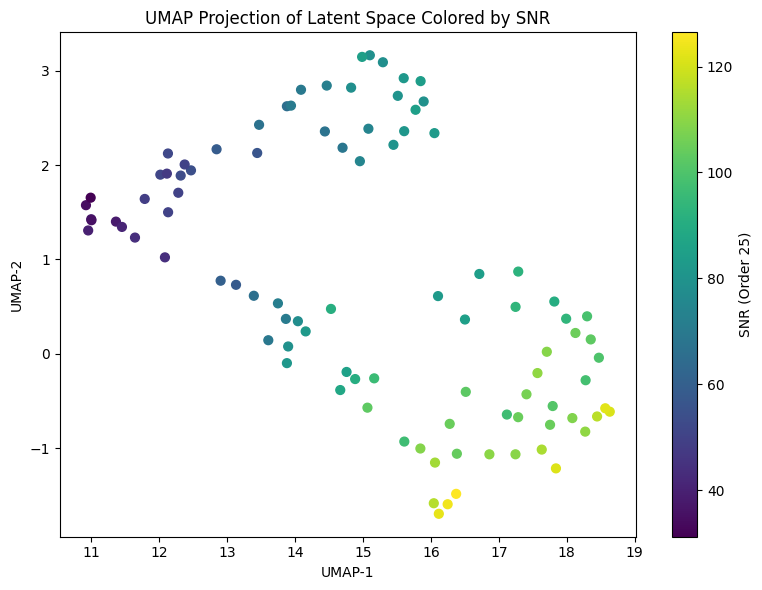

In [28]:
print(Z.shape, len(SNR_25))

# Project latent space to 2D
reducer = umap.UMAP(random_state=42)
Z_umap = reducer.fit_transform(Z)

# Plot UMAP with SNR coloring
plt.figure(figsize=(8, 6))
sc = plt.scatter(Z_umap[:, 0], Z_umap[:, 1], c=SNR_25[:len(Z_umap)], cmap='viridis', s=40)
plt.colorbar(sc, label="SNR (Order 25)")
plt.title("UMAP Projection of Latent Space Colored by SNR")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

### Spearman Correlation

In [29]:
corr_umap1, _ = spearmanr(Z_umap[:, 0], SNR_25[:len(Z_umap)])
corr_umap2, _ = spearmanr(Z_umap[:, 1], SNR_25[:len(Z_umap)])

print(f"Spearman corr with UMAP-1: {corr_umap1:.3f}")
print(f"Spearman corr with UMAP-2: {corr_umap2:.3f}")

Spearman corr with UMAP-1: 0.897
Spearman corr with UMAP-2: -0.731


## Correlation Matrix: Latent Space vs. Activity Indicators

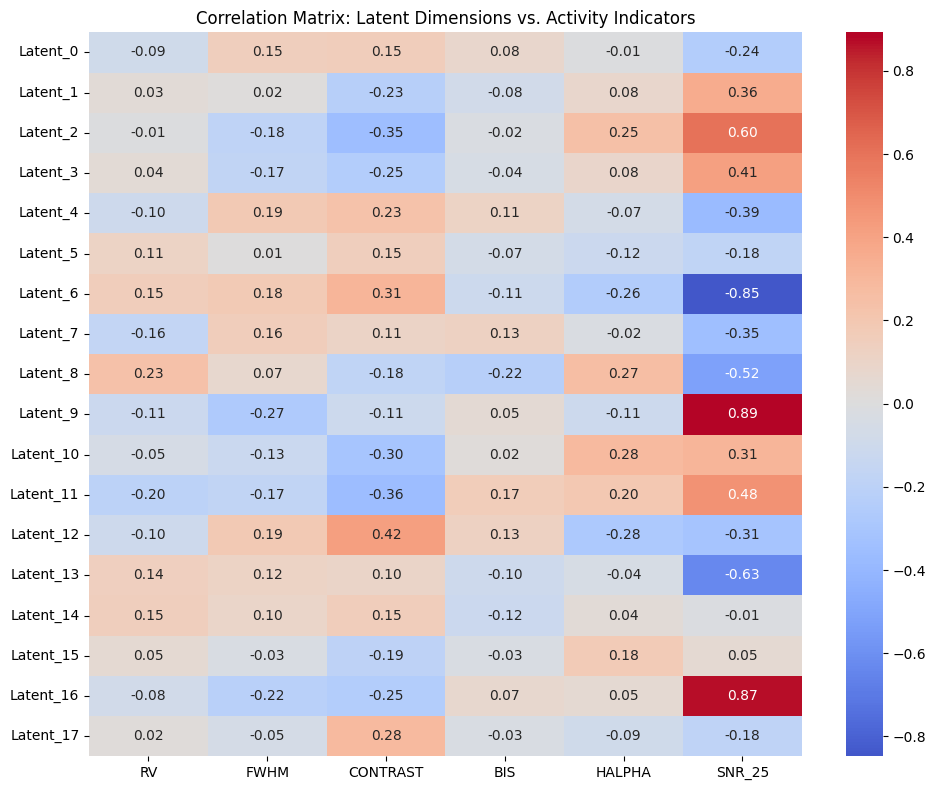

In [30]:
# Combine latent vectors with metadata
latent_df = pd.DataFrame(Z, columns=[f"Latent_{i}" for i in range(Z.shape[1])])
combined_df = pd.concat([latent_df, meta.reset_index(drop=True)], axis=1)

# Select only relevant activity indicators
activity_cols = ['RV', 'FWHM', 'CONTRAST', 'BIS', 'HALPHA', 'SNR_25']
corr_matrix = combined_df[[f"Latent_{i}" for i in range(Z.shape[1])] + activity_cols].corr()
corr_subset = corr_matrix.loc[[f"Latent_{i}" for i in range(Z.shape[1])], activity_cols]

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Latent Dimensions vs. Activity Indicators")
plt.tight_layout()
plt.show()

## Lomb-Scargle on Latent Vectors

Note, that AU-MIC has a a rotation period of about 4.86 days - meaning it rotates once every ~4.8367 days. (This is corresponding to ~0.206 cycles/day).

https://www.aanda.org/articles/aa/full_html/2021/10/aa40345-21/aa40345-21.html

In [31]:
time = combined_df['BJD'].values

# Frequency range
min_freq = 1 / 100   
max_freq = 0.5   
frequencies = np.linspace(min_freq, max_freq, 10000)

# False alarm levels
fap_levels = [0.001, 0.01, 0.10]  # 0.1%, 1%, 10%

# actual rotation frequency of AU-Mic
rotation_freq = 1 / 4.8367  # 4.8367 ± 0.0006 day

# Second harmonic frequency
second_harmonic = 2 * rotation_freq  # ≈ 0.412

# Store results
powers = []
peak_freqs = []
faps = []
fap_thresholds_all = []

for i in range(Z.shape[1]):
    latent_series = latent_df[f"Latent_{i}"].values
    ls = LombScargle(time, latent_series)
    power = ls.power(frequencies)
    powers.append(power)
    best_freq = frequencies[np.argmax(power)]
    peak_freqs.append(best_freq)
    fap = ls.false_alarm_probability(np.max(power))
    faps.append(fap)
    fap_thresholds = [ls.false_alarm_level(level) for level in fap_levels]
    fap_thresholds_all.append(fap_thresholds)

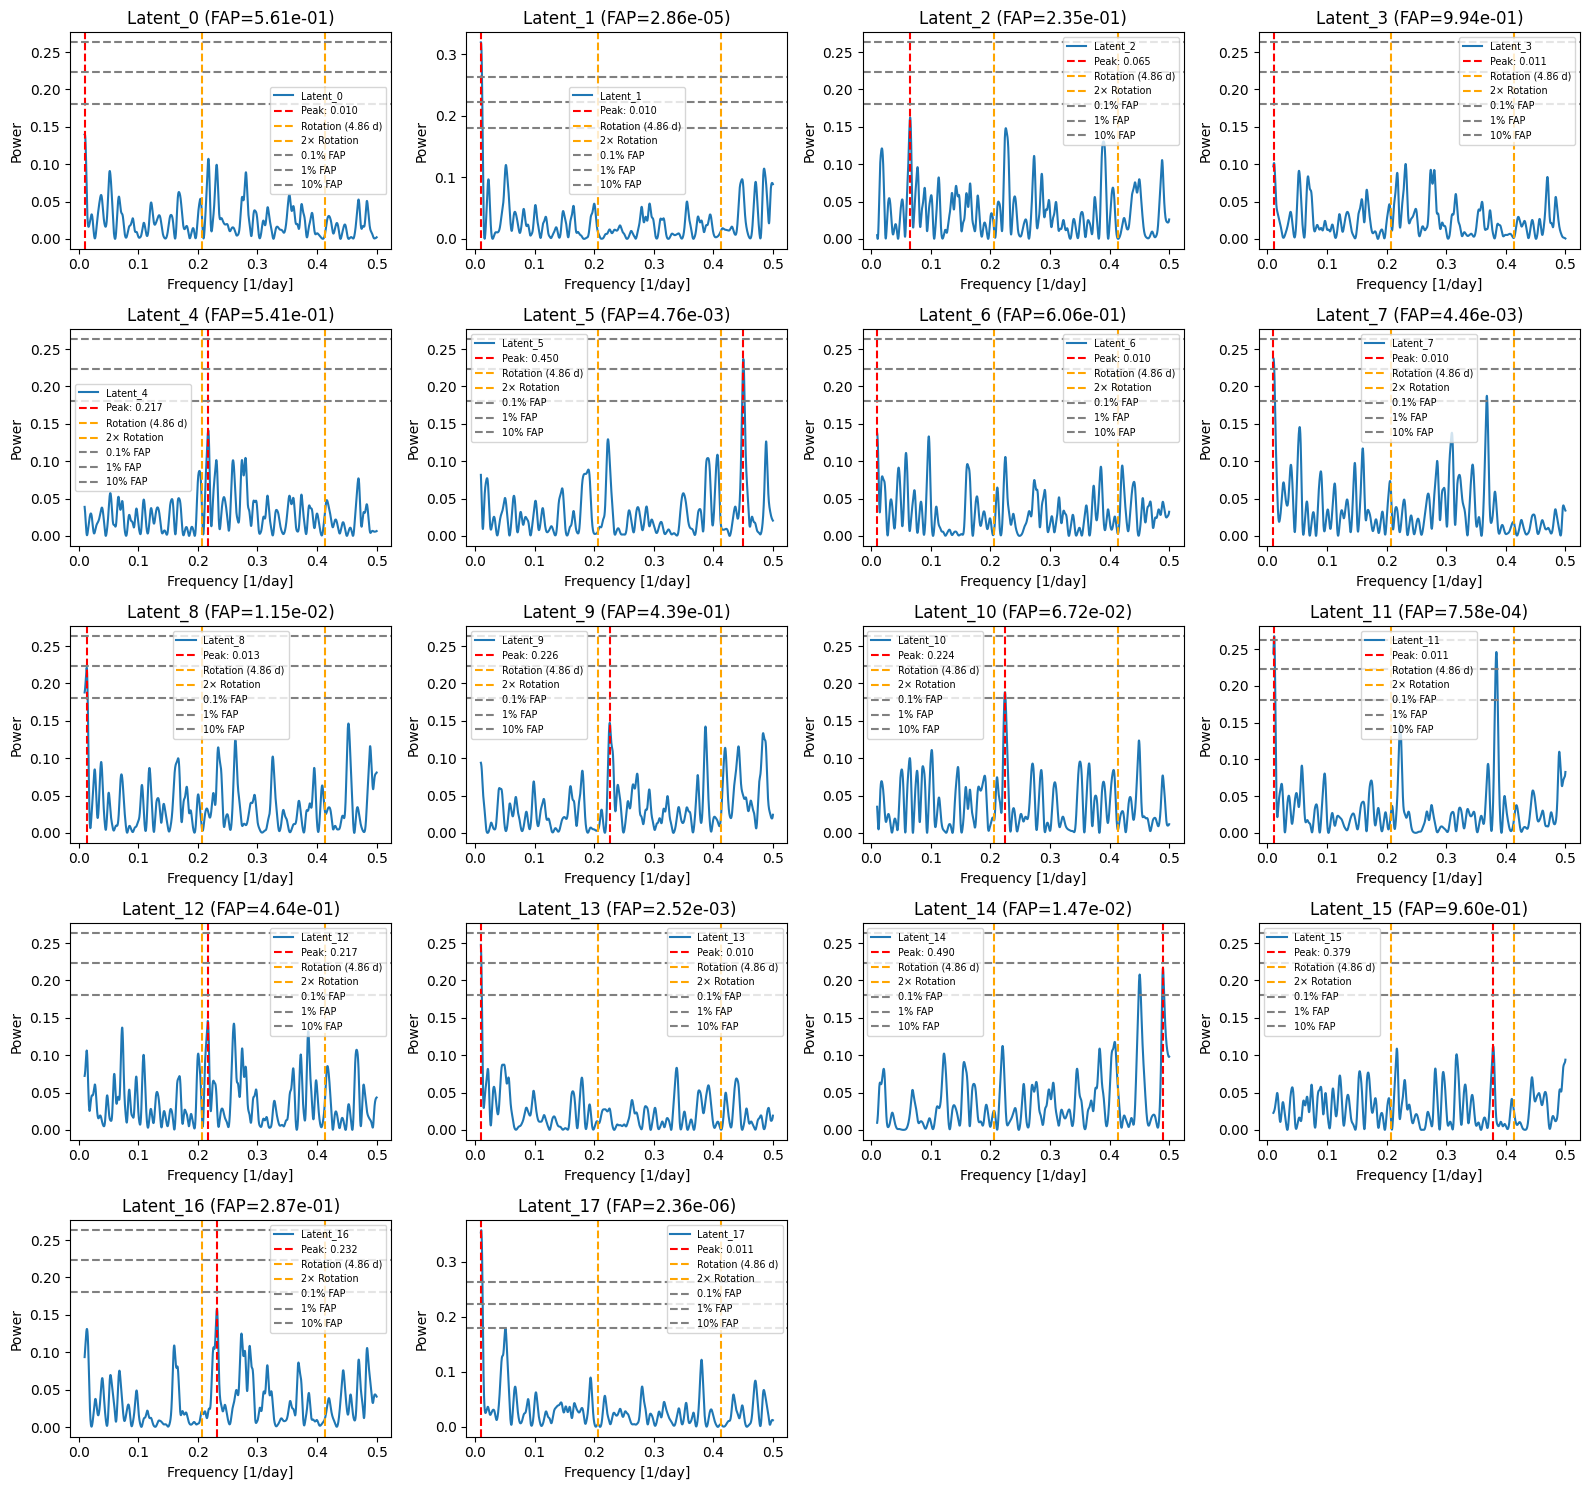

In [32]:
n_latents = Z.shape[1]
ncols = 4
nrows = int(np.ceil(n_latents / ncols))

plt.figure(figsize=(16, 3 * nrows))

for i in range(n_latents):
    plt.subplot(nrows, ncols, i + 1)
    plt.plot(frequencies, powers[i], label=f"Latent_{i}")
    plt.axvline(peak_freqs[i], color="red", linestyle="--", label=f"Peak: {peak_freqs[i]:.3f}")
    plt.axvline(rotation_freq, color='orange', linestyle='--', label='Rotation (4.86 d)')
    plt.axvline(second_harmonic, color='orange', linestyle='--', label='2× Rotation')
    plt.axhline(fap_thresholds_all[i][0], color='gray', linestyle='--', label='0.1% FAP')
    plt.axhline(fap_thresholds_all[i][1], color='gray', linestyle='--', label='1% FAP')
    plt.axhline(fap_thresholds_all[i][2], color='gray', linestyle='--', label='10% FAP')
    plt.title(f"Latent_{i} (FAP={faps[i]:.2e})")
    plt.xlabel("Frequency [1/day]")
    plt.ylabel("Power")
    plt.legend(fontsize='x-small')

plt.tight_layout()
plt.show()

In [33]:
summary_df = pd.DataFrame({
    "Latent Dimension": [f"Latent_{i}" for i in range(Z.shape[1])],
    "Peak Frequency": peak_freqs,
    "FAP": faps
})

summary_df = summary_df.sort_values("FAP")
display(summary_df)

,Latent Dimension,Peak Frequency,FAP
17,Latent_17,0.010588,0.000002
1,Latent_1,0.010098,0.000029
11,Latent_11,0.011323,0.000758
13,Latent_13,0.010000,0.002524
7,Latent_7,0.010000,0.004465
5,Latent_5,0.450407,0.004757
8,Latent_8,0.013381,0.011471
14,Latent_14,0.489611,0.014746
10,Latent_10,0.224494,0.067229
2,Latent_2,0.065376,0.234860


#### True H-alpha

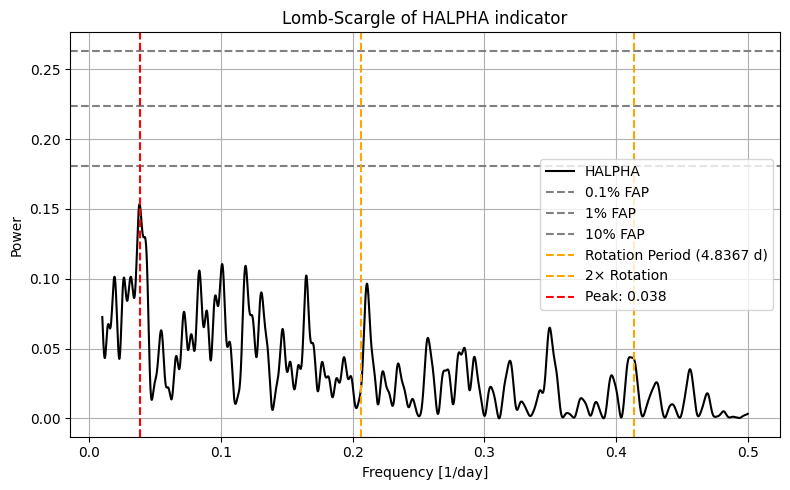

Best period: 26.126 days


In [34]:
halpha = combined_df['HALPHA'].values
halpha = halpha - np.mean(halpha)  # remove DC offset

# Compute Lomb-Scargle
ls = LombScargle(time, halpha)
halpha_power = ls.power(frequencies)

# False alarm levels
fap_01 = ls.false_alarm_level(0.001)
fap_1 = ls.false_alarm_level(0.01)
fap_10 = ls.false_alarm_level(0.1)

# Peak frequency
best_freq = frequencies[np.argmax(halpha_power)]
best_period = 1 / best_freq
second_harmonic = 2 * rotation_freq

# Plot
plt.figure(figsize=(8, 5))
plt.plot(frequencies, halpha_power, label="HALPHA", color="black")
plt.axhline(fap_01, color='gray', linestyle='--', label='0.1% FAP')
plt.axhline(fap_1, color='gray', linestyle='--', label='1% FAP')
plt.axhline(fap_10, color='gray', linestyle='--', label='10% FAP')
plt.axvline(rotation_freq, color='orange', linestyle='--', label='Rotation Period (4.8367 d)')
plt.axvline(second_harmonic, color='orange', linestyle='--', label='2× Rotation')
plt.axvline(best_freq, color='red', linestyle='--', label=f'Peak: {best_freq:.3f}')
plt.xlabel("Frequency [1/day]")
plt.ylabel("Power")
plt.title("Lomb-Scargle of HALPHA indicator")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best period: {best_period:.3f} days")

### Lomb-Scargle for RV, BIS, FWHM

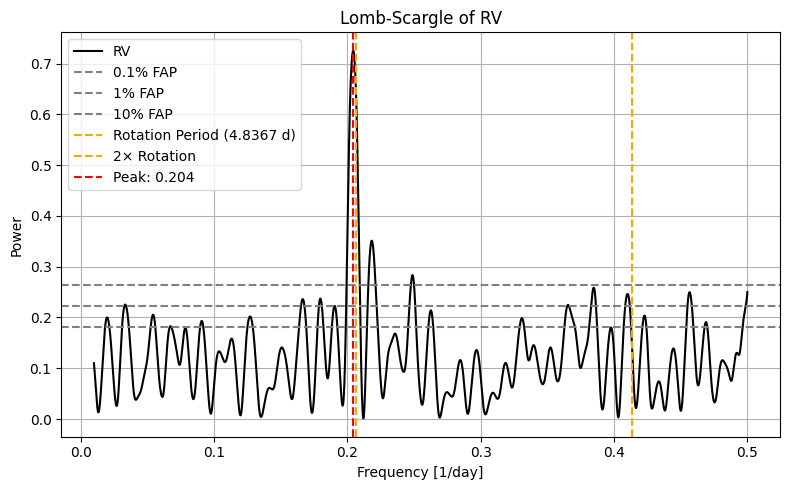

RV — Best period: 4.891 days



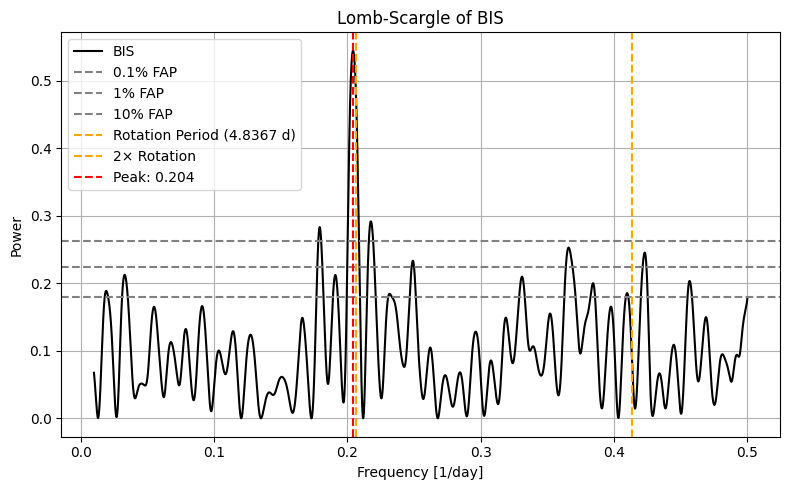

BIS — Best period: 4.895 days



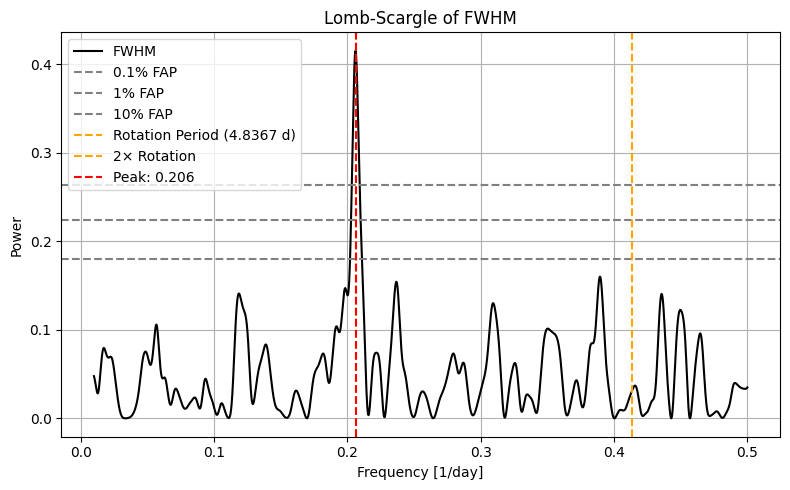

FWHM — Best period: 4.850 days



In [35]:
indicators = ["RV", "BIS", "FWHM"]

for col in indicators:
    y = combined_df[col].values
    y = y - np.mean(y)  # remove DC offset

    # Lomb-Scargle periodogram
    ls = LombScargle(time, y)
    power = ls.power(frequencies)

    # FAP thresholds
    fap_01 = ls.false_alarm_level(0.001)
    fap_1 = ls.false_alarm_level(0.01)
    fap_10 = ls.false_alarm_level(0.1)

    # Peak
    best_freq = frequencies[np.argmax(power)]
    best_period = 1 / best_freq
    second_harmonic = 2 * rotation_freq

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(frequencies, power, label=col, color="black")
    plt.axhline(fap_01, color='gray', linestyle='--', label='0.1% FAP')
    plt.axhline(fap_1, color='gray', linestyle='--', label='1% FAP')
    plt.axhline(fap_10, color='gray', linestyle='--', label='10% FAP')
    plt.axvline(rotation_freq, color='orange', linestyle='--', label='Rotation Period (4.8367 d)')
    plt.axvline(second_harmonic, color='orange', linestyle='--', label='2× Rotation')
    plt.axvline(best_freq, color='red', linestyle='--', label=f'Peak: {best_freq:.3f}')
    plt.xlabel("Frequency [1/day]")
    plt.ylabel("Power")
    plt.title(f"Lomb-Scargle of {col}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"{col} — Best period: {best_period:.3f} days\n")


### A constant signal with our observation times

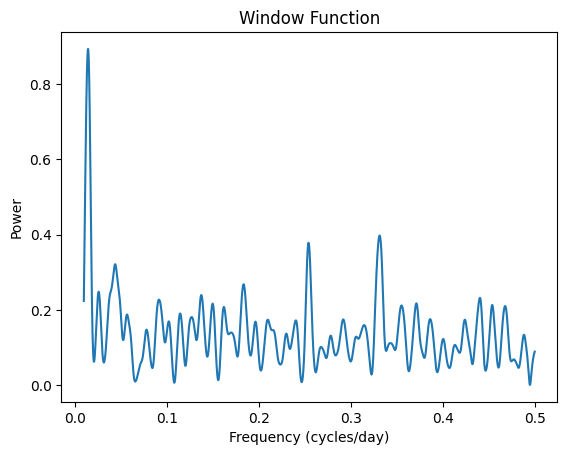

In [36]:
dummy_signal = np.ones_like(time)
ls_window = LombScargle(time, dummy_signal)
power_window = ls_window.power(frequencies)

plt.plot(frequencies, power_window)
plt.title("Window Function")
plt.xlabel("Frequency (cycles/day)")
plt.ylabel("Power")
plt.show()

## GIF of Evolution

In [37]:
print(autoencoder.input_shape)

(None, 1472, 1)


In [38]:
os.makedirs("gif_frames", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Reconstruct
recon = autoencoder.predict(X_crop)

# Determine global limits
y_min = min(np.min(X_crop), np.min(recon))
y_max = max(np.max(X_crop), np.max(recon))
x_min = 0
x_max = X_crop.shape[1]  # number of pixels in cropped order

# Plot & save individual frames with fixed axes
for i in range(len(X_crop)):
    plt.figure(figsize=(8, 4))
    plt.plot(X_crop[i].squeeze(), label="Original", color='black')
    plt.plot(recon[i].squeeze(), label="Reconstructed", linestyle='--', color='blue')
    plt.title(f"Obs {i+1} — BJD: {time[i]:.2f}")
    plt.legend()
    plt.xlabel("Pixel")
    plt.ylabel("Normalized Flux")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.tight_layout()
    plt.savefig(f"gif_frames/frame_{i:03}.png")
    plt.close()

# Assemble GIF
images = [imageio.imread(f"gif_frames/frame_{i:03}.png") for i in range(len(X_crop))]
imageio.mimsave("outputs/ha_evolution.gif", images, fps=2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


/tmp/ipykernel_10430/3995699883.py:29: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(f"gif_frames/frame_{i:03}.png") for i in range(len(X_crop))]
